# Multi-Channel SCADA-Based Image-Driven Power Prediction for Wind Turbines Using Optimized LeNet-5-LSTM Hybrid Neural Architecture

#### Author: Dr. M. Ahsan
#### https://m-ahsan09.github.io/projects.html

- This notebook introduces the SCADA dataset from Poland Wind Turbine
- After visualization of different parameters: This notebook prepare the dataset for ML model
- The ML model is trained and results are computed


#### Related Paper:
- Ahsan, M., & Dao, P. B. (2026). Multi-Channel SCADA-Based Image-Driven Power Prediction for Wind Turbines Using Optimized LeNet-5-LSTM Hybrid Neural Architecture. Energies, 19(5), 1169.
- DOI: https://doi.org/10.3390/en19051169

#### The columns descriptions:

- Date/Time : readings for 10 minutes intervals in 2012

- Active Power | Reactive power | 
- Wind speed | Rotor speed | Generator speed |
- Voltage | Current |
- Generator temperature 1 | Generator temperature 2 | Gearbox temperature |
- Active power delivered | Reactive power delivered

In [1]:
#!pip install xgboost

In [2]:
##conda install -c conda-forge pyts

In [3]:
# Create new environment named pyts_env with Python 3.8
#!conda create -n pyts_env python=3.8 -y

# Activate the environment
#!conda activate pyts_env

# Install pyts in the new environment
#!conda install -c conda-forge pyts -y



In [4]:
import os
import random
import numpy as np
import tensorflow as tf
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, LSTM, Reshape, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.initializers import GlorotUniform
from tensorflow.keras import regularizers


C:\Users\Think\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [5]:
figs = r"C:\Users\Think\Desktop\Energies-MPDI-Code"

In [6]:
# Load the CSV file
file = "P04.1_NegativePower_SCADA_Poland.csv"
data = pd.read_csv(f"{figs}\\{file}")

# Display the first 5 rows
data.head()


,Active Power (kW),Reactive Power (kVAr),Wind Speed (m/s),Shaft Speed (RPM),Generator Temperature (°C),Gearbox Temperature (°C),Voltage (V),Current (A)
0,801.22740,174.30330,7.739194,1065.24195,50.470228,65.804250,671.57940,695.42460
1,740.52264,164.16277,7.570996,1040.97755,54.503658,66.093420,670.65720,644.31690
2,708.91815,148.30557,7.704981,1022.27198,58.030823,66.003790,669.15850,616.05160
3,745.69073,153.17044,7.733267,1042.33660,57.947770,65.725815,668.08480,649.26680
4,750.74817,151.91812,7.551532,1043.77985,55.528790,65.239420,668.40924,653.03284


### Data Preparation

#### Renaming Columns:
- Rename the variabes if required

In [7]:
df = data.copy()

In [8]:
df.describe()

,Active Power (kW),Reactive Power (kVAr),Wind Speed (m/s),Shaft Speed (RPM),Generator Temperature (°C),Gearbox Temperature (°C),Voltage (V),Current (A)
count,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000,4320.000000
mean,564.312980,120.947784,6.517456,855.159312,52.259839,59.855957,664.732100,498.227594
std,508.757346,178.678837,2.277021,293.968546,9.505954,8.534551,15.629925,456.354133
min,-3.561004,-61.487183,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,190.959007,0.000000,5.108265,823.762434,48.475869,58.399195,661.167875,163.079625
50%,444.297020,58.642771,6.600123,898.104750,51.371206,61.339818,664.318030,387.337080
75%,788.818178,159.836610,7.914281,1044.727500,55.081808,65.144145,667.930375,697.583325
max,2516.132600,918.954500,13.751790,1158.924100,97.708375,70.550910,688.039600,2243.885700


In [9]:
##################################################################################

In [10]:
win_len = 36
stride = 3

# Initialize scalers
scaler_wind = MinMaxScaler(feature_range=(-1, 1))
scaler_shaft = MinMaxScaler(feature_range=(-1, 1))
scaler_gen_t = MinMaxScaler(feature_range=(-1, 1))
scaler_gear_t = MinMaxScaler(feature_range=(-1, 1))
scaler_current = MinMaxScaler(feature_range=(-1, 1))
scaler_volt = MinMaxScaler(feature_range=(-1, 1))
scaler_power = MinMaxScaler(feature_range=(-1, 1))

wind_scaled = scaler_wind.fit_transform(df['Wind Speed (m/s)'].values.reshape(-1,1)).flatten()
shaft_scaled = scaler_shaft.fit_transform(df['Shaft Speed (RPM)'].values.reshape(-1,1)).flatten()

gen_t_scaled = scaler_gen_t.fit_transform(df['Generator Temperature (°C)'].values.reshape(-1,1)).flatten()
gear_t_scaled = scaler_gear_t.fit_transform(df['Gearbox Temperature (°C)'].values.reshape(-1,1)).flatten()

current_scaled = scaler_current.fit_transform(df['Current (A)'].values.reshape(-1,1)).flatten()
voltage_scaled = scaler_volt.fit_transform(df['Voltage (V)'].values.reshape(-1,1)).flatten()
power_scaled = scaler_power.fit_transform(df[['Active Power (kW)', 'Reactive Power (kVAr)']].values)

X_wind, X_shaft, X_gen_t, X_gear_t, X_current, X_voltage = [], [], [], [], [], []
Y = []

for i in range(0, len(df) - win_len + 1, stride):
    wind_win = wind_scaled[i:i+win_len]
    shaft_win = shaft_scaled[i:i+win_len]
    gen_t_win = gen_t_scaled[i:i+win_len]
    gear_t_win = gear_t_scaled[i:i+win_len]
    current_win = current_scaled[i:i+win_len]
    volt_win = voltage_scaled[i:i+win_len]
    
    X_wind.append(np.tile(wind_win.reshape(-1,1), (1, win_len)))
    X_shaft.append(np.tile(shaft_win.reshape(-1,1), (1, win_len)))
    X_gen_t.append(np.tile(gen_t_win.reshape(-1,1), (1, win_len)))
    X_gear_t.append(np.tile(gear_t_win.reshape(-1,1), (1, win_len)))
    X_current.append(np.tile(current_win.reshape(-1,1), (1, win_len)))
    X_voltage.append(np.tile(volt_win.reshape(-1,1), (1, win_len)))
    
    Y.append(power_scaled[i+win_len-1]) 
    
X_wind = np.array(X_wind)[..., np.newaxis]
X_shaft = np.array(X_shaft)[..., np.newaxis]
X_gen_t = np.array(X_gen_t)[..., np.newaxis]
X_gear_t = np.array(X_gear_t)[..., np.newaxis]
X_current = np.array(X_current)[..., np.newaxis]
X_voltage = np.array(X_voltage)[..., np.newaxis]
Y = np.array(Y) 

# Print shapes
print("Shapes:")
print("X_wind:", X_wind.shape)
print("X_shaft:", X_shaft.shape)
print("X_gen_t:", X_gen_t.shape)
print("X_gear_t:", X_gear_t.shape)
print("X_current:", X_current.shape)
print("X_voltage:", X_voltage.shape)
print("Y:", Y.shape)


Shapes:
X_wind: (1429, 36, 36, 1)
X_shaft: (1429, 36, 36, 1)
X_gen_t: (1429, 36, 36, 1)
X_gear_t: (1429, 36, 36, 1)
X_current: (1429, 36, 36, 1)
X_voltage: (1429, 36, 36, 1)
Y: (1429, 2)


In [11]:
###############################################################################################

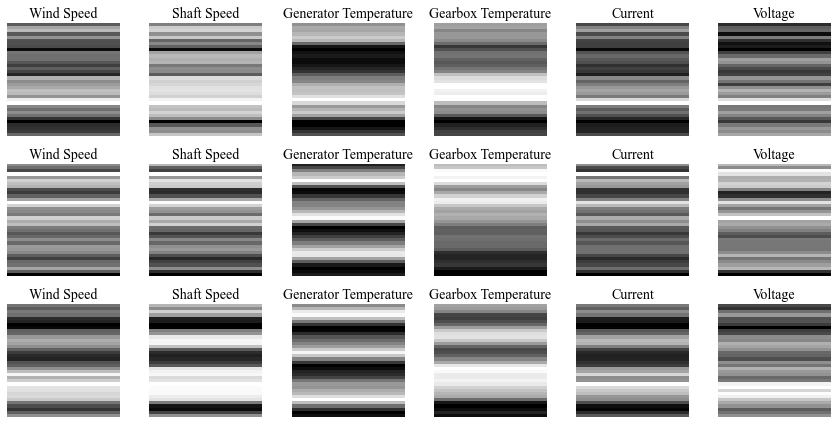

Reactive Power figure saved at: C:\Users\Think\Desktop\Energies-MPDI-Code\F01_Grayscale_D01.png


In [12]:
# Apply Times New Roman font globally
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

def plot_random_grayscale_images(X_wind, X_shaft, X_gen_t, X_gear_t, X_current, X_voltage, num_samples=3):
    indices = random.sample(range(len(X_wind)), num_samples)
    
    plt.figure(figsize=(12, 2*num_samples))
    
    for i, idx in enumerate(indices):
        # Head 1 - Wind Speed
        plt.subplot(num_samples, 6, i*6 + 1)
        plt.imshow(X_wind[idx, :, :, 0], cmap='gray', origin='lower')
        plt.title(f"Wind Speed")
        plt.axis('off')
        
        # Head 2 - Shaft Speed
        plt.subplot(num_samples, 6, i*6 + 2)
        plt.imshow(X_shaft[idx, :, :, 0], cmap='gray', origin='lower')
        plt.title(f"Shaft Speed")
        plt.axis('off')
        
        # Head 3 - Generator Temperature
        plt.subplot(num_samples, 6, i*6 + 3)
        plt.imshow(X_gen_t[idx, :, :, 0], cmap='gray', origin='lower')
        plt.title(f"Generator Temperature")
        plt.axis('off')
        
        # Head 4 - Gearbox Temperature
        plt.subplot(num_samples, 6, i*6 + 4)
        plt.imshow(X_gear_t[idx, :, :, 0], cmap='gray', origin='lower')
        plt.title(f"Gearbox Temperature")
        plt.axis('off')
        
        # Head 5 - Current
        plt.subplot(num_samples, 6, i*6 + 5)
        plt.imshow(X_current[idx, :, :, 0], cmap='gray', origin='lower')
        plt.title(f"Current")
        plt.axis('off')
        
        # Head 6 - Voltage
        plt.subplot(num_samples, 6, i*6 + 6)
        plt.imshow(X_voltage[idx, :, :, 0], cmap='gray', origin='lower')
        plt.title(f"Voltage")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Plot 3 random samples
plot_random_grayscale_images(X_wind, X_shaft, X_gen_t, X_gear_t, X_current, X_voltage, num_samples=3)


In [13]:
from sklearn.model_selection import train_test_split

X_wind_train, X_wind_test, \
X_shaft_train, X_shaft_test, \
X_gen_t_train, X_gen_t_test, \
X_gear_t_train, X_gear_t_test, \
X_current_train, X_current_test, \
X_voltage_train, X_voltage_test, \
y_train, y_test = train_test_split(
    X_wind, X_shaft, X_gen_t, X_gear_t, X_current, X_voltage, Y,  # include X_Ssq
    test_size=0.3,
    shuffle=True,
    random_state=36
)

print("X_wind_train:", X_wind_train.shape)
print("y_train:", y_train.shape)
print("X_wind_test:", X_wind_test.shape)
print("y_test:", y_test.shape)


X_wind_train: (1000, 36, 36, 1)
y_train: (1000, 2)
X_wind_test: (429, 36, 36, 1)
y_test: (429, 2)


In [14]:
def create_cnn_lstm_model(input_shape, num_outputs=2, dropout_rate=0.3):
    
    def create_head(inputs):
        x = Conv2D(12, (8,8), activation='tanh', padding='same')(inputs)
        x = MaxPooling2D((3,3), strides=2)(x)
        x = Conv2D(8, (6,6), activation='tanh', padding='same')(x)
        x = MaxPooling2D((3,3), strides=2)(x)
        x = Flatten()(x)
        return x

    # --- INPUT HEADS ---
    inputs1 = Input(shape=input_shape)
    head1 = create_head(inputs1)

    inputs2 = Input(shape=input_shape)
    head2 = create_head(inputs2)

    inputs3 = Input(shape=input_shape)
    head3 = create_head(inputs3)
    
    inputs4 = Input(shape=input_shape)
    head4 = create_head(inputs4)
    
    inputs5 = Input(shape=input_shape)
    head5 = create_head(inputs5)
    
    inputs6 = Input(shape=input_shape)
    head6 = create_head(inputs6)

    merged = Concatenate()([head1, head2, head3, head4, head5, head6])
    merged = Dense(128, activation='tanh', kernel_initializer=GlorotUniform())(merged) 
    merged = Dropout(dropout_rate)(merged)

    reshaped = Reshape((1, 128))(merged) 
    lstm_out = LSTM(64, return_sequences=True)(reshaped)
    lstm_out = LSTM(32, return_sequences=False)(lstm_out)

    outputs = Dense(num_outputs, activation='linear')(lstm_out)

    model = Model(inputs=[inputs1, inputs2, inputs3, inputs4, inputs5, inputs6], outputs=outputs)

    opt = Adam(learning_rate=5e-4, clipnorm=1.0)
    # model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    model.compile(optimizer=opt,
                  loss=physics_guided_loss,  # MSE-only for now
                  metrics=[])
    
    return model


In [15]:
def data_loss_metric(y_true, y_pred):
    P_true, Q_true = y_true[:, 0], y_true[:, 1]
    P_pred, Q_pred = y_pred[:, 0], y_pred[:, 1]
    return tf.reduce_mean(tf.square(P_true - P_pred) + tf.square(Q_true - Q_pred))

def phys_loss_metric(y_true, y_pred):
    P_pred, Q_pred = y_pred[:, 0], y_pred[:, 1]
    P_true, Q_true = y_true[:, 0], y_true[:, 1]
    S_sq = P_true**2 + Q_true**2
    return tf.reduce_mean(tf.square((P_pred**2 + Q_pred**2) - S_sq))

def physics_guided_loss(y_true, y_pred, alpha=0.7):
    data_loss = tf.reduce_mean(tf.square(y_true - y_pred))
    phys_loss = tf.reduce_mean(tf.square((y_pred[:,0]**2 + y_pred[:,1]**2) - (y_true[:,0]**2 + y_true[:,1]**2)))
    return alpha * data_loss + (1 - alpha) * phys_loss

def mse_metric(y_true, y_pred):
    # standard MSE of predictions vs true outputs
    P_true, Q_true = y_true[:, 0], y_true[:, 1]
    P_pred, Q_pred = y_pred[:, 0], y_pred[:, 1]
    return tf.reduce_mean(tf.square(P_true - P_pred) + tf.square(Q_true - Q_pred))


In [16]:
num_runs = 5
batch_size = 32
epochs = 50
input_shape = (36, 36, 1)  # Grayscale images

# Placeholders for metrics
res_mae = np.empty((num_runs, y_train.shape[1]))   # columns = Active Power, Reactive Power
res_rmse = np.empty((num_runs, y_train.shape[1]))
res_r2 = np.empty((num_runs, y_train.shape[1]))

# Placeholders for histories and best model
histories = []
results  = []
best_model = None
best_history = None
best_total_mae = None

lr_schedule = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)


In [17]:
for run in range(num_runs):
    print(f"\n===== Training Iteration {run+1} =====\n")
    
    model = create_cnn_lstm_model(input_shape=input_shape, num_outputs=y_train.shape[1])
    
    if run == 0:
        model.summary()
      
    model.compile(
        optimizer='adam',
        loss=lambda y_true, y_pred: physics_guided_loss(y_true, y_pred, alpha=0.7),
        metrics=[data_loss_metric, phys_loss_metric, mse_metric]
    )

    history = model.fit(
        [X_wind_train, X_shaft_train, X_gen_t_train, X_gear_t_train, X_current_train, X_voltage_train], y_train,
        validation_data=([X_wind_test, X_shaft_test, X_gen_t_test, X_gear_t_test, X_current_test, X_voltage_test], y_test),
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        callbacks=[lr_schedule],
        verbose=1
    )
    
    histories.append(history)
    
    y_pred = model.predict([X_wind_test, X_shaft_test, X_gen_t_test, X_gear_t_test, X_current_test, X_voltage_test],
                           batch_size=batch_size)
    
    for j, name in enumerate(['Active Power', 'Reactive Power']):
        res_mae[run, j]  = mean_absolute_error(y_test[:, j], y_pred[:, j])
        mse = mean_squared_error(y_test[:, j], y_pred[:, j])
        rmse = np.sqrt(mse)
        res_rmse[run, j] = rmse
        res_r2[run, j]   = r2_score(y_test[:, j], y_pred[:, j])

    total_mae = np.sum(res_mae[run, :])
    results.append({
        'Run': run + 1,
        'MAE_Active': res_mae[run, 0],
        'MAE_Reactive': res_mae[run, 1],
        'RMSE_Active': res_rmse[run, 0],
        'RMSE_Reactive': res_rmse[run, 1],
        'R2_Active': res_r2[run, 0],
        'R2_Reactive': res_r2[run, 1],
        'Total_MAE': total_mae
    })

    if best_model is None or total_mae < best_total_mae:
        best_model = model
        best_model.set_weights(model.get_weights())
        best_history = history.history
        best_total_mae = total_mae

print("\nTraining complete. Best total MAE:", best_total_mae)



===== Training Iteration 1 =====

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 36, 36, 1)]  0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 36, 36, 1)]  0           []                               
                                                                                                  
 input_3 (InputLayer)           [(None, 36, 36, 1)]  0           []                               
                                                                                                  
 input_4 (InputLayer)           [(None, 36, 36, 1)]  0           []                               
                                                           

                                                                                                  
 dense (Dense)                  (None, 128)          393344      ['concatenate[0][0]']            
                                                                                                  
 dropout (Dropout)              (None, 128)          0           ['dense[0][0]']                  
                                                                                                  
 reshape (Reshape)              (None, 1, 128)       0           ['dropout[0][0]']                
                                                                                                  
 lstm (LSTM)                    (None, 1, 64)        49408       ['reshape[0][0]']                
                                                                                                  
 lstm_1 (LSTM)                  (None, 32)           12416       ['lstm[0][0]']                   
          

Epoch 23/50
32/32 [==============================] - 8s 247ms/step - loss: 0.0058 - data_loss_metric: 0.0073 - phys_loss_metric: 0.0116 - mse_metric: 0.0073 - val_loss: 0.0063 - val_data_loss_metric: 0.0078 - val_phys_loss_metric: 0.0123 - val_mse_metric: 0.0078 - lr: 5.0000e-04
Epoch 24/50
32/32 [==============================] - 8s 249ms/step - loss: 0.0061 - data_loss_metric: 0.0069 - phys_loss_metric: 0.0119 - mse_metric: 0.0069 - val_loss: 0.0065 - val_data_loss_metric: 0.0083 - val_phys_loss_metric: 0.0123 - val_mse_metric: 0.0083 - lr: 5.0000e-04
Epoch 25/50
32/32 [==============================] - 8s 246ms/step - loss: 0.0048 - data_loss_metric: 0.0060 - phys_loss_metric: 0.0088 - mse_metric: 0.0060 - val_loss: 0.0043 - val_data_loss_metric: 0.0060 - val_phys_loss_metric: 0.0079 - val_mse_metric: 0.0060 - lr: 5.0000e-04
Epoch 26/50
32/32 [==============================] - 8s 250ms/step - loss: 0.0052 - data_loss_metric: 0.0060 - phys_loss_metric: 0.0099 - mse_metric: 0.0060 - v

32/32 [==============================] - 8s 250ms/step - loss: 0.0034 - data_loss_metric: 0.0042 - phys_loss_metric: 0.0063 - mse_metric: 0.0042 - val_loss: 0.0033 - val_data_loss_metric: 0.0048 - val_phys_loss_metric: 0.0060 - val_mse_metric: 0.0048 - lr: 3.1250e-05
Epoch 50/50
14/14 [==============================] - 2s 58ms/step

===== Training Iteration 2 =====

Epoch 1/50
32/32 [==============================] - 18s 281ms/step - loss: 0.2084 - data_loss_metric: 0.2349 - phys_loss_metric: 0.4074 - mse_metric: 0.2349 - val_loss: 0.0689 - val_data_loss_metric: 0.0936 - val_phys_loss_metric: 0.1303 - val_mse_metric: 0.0936 - lr: 0.0010
Epoch 2/50
32/32 [==============================] - 8s 238ms/step - loss: 0.0588 - data_loss_metric: 0.0670 - phys_loss_metric: 0.1163 - mse_metric: 0.0670 - val_loss: 0.0425 - val_data_loss_metric: 0.0530 - val_phys_loss_metric: 0.0850 - val_mse_metric: 0.0530 - lr: 0.0010
Epoch 3/50
32/32 [==============================] - 8s 240ms/step - loss: 0.0331

Epoch 27/50
32/32 [==============================] - 8s 247ms/step - loss: 0.0045 - data_loss_metric: 0.0055 - phys_loss_metric: 0.0086 - mse_metric: 0.0055 - val_loss: 0.0038 - val_data_loss_metric: 0.0053 - val_phys_loss_metric: 0.0069 - val_mse_metric: 0.0053 - lr: 2.5000e-04
Epoch 28/50
32/32 [==============================] - 8s 241ms/step - loss: 0.0047 - data_loss_metric: 0.0059 - phys_loss_metric: 0.0088 - mse_metric: 0.0059 - val_loss: 0.0041 - val_data_loss_metric: 0.0061 - val_phys_loss_metric: 0.0072 - val_mse_metric: 0.0061 - lr: 2.5000e-04
Epoch 29/50
32/32 [==============================] - 8s 242ms/step - loss: 0.0051 - data_loss_metric: 0.0061 - phys_loss_metric: 0.0097 - mse_metric: 0.0061 - val_loss: 0.0034 - val_data_loss_metric: 0.0054 - val_phys_loss_metric: 0.0057 - val_mse_metric: 0.0054 - lr: 2.5000e-04
Epoch 30/50
32/32 [==============================] - 8s 241ms/step - loss: 0.0048 - data_loss_metric: 0.0061 - phys_loss_metric: 0.0101 - mse_metric: 0.0061 - v

...

32/32 [==============================] - 8s 252ms/step - loss: 0.0048 - data_loss_metric: 0.0054 - phys_loss_metric: 0.0097 - mse_metric: 0.0054 - val_loss: 0.0040 - val_data_loss_metric: 0.0059 - val_phys_loss_metric: 0.0068 - val_mse_metric: 0.0059 - lr: 1.2500e-04
Epoch 30/50
32/32 [==============================] - 9s 271ms/step - loss: 0.0045 - data_loss_metric: 0.0055 - phys_loss_metric: 0.0084 - mse_metric: 0.0055 - val_loss: 0.0033 - val_data_loss_metric: 0.0051 - val_phys_loss_metric: 0.0057 - val_mse_metric: 0.0051 - lr: 1.2500e-04
Epoch 31/50
32/32 [==============================] - 8s 258ms/step - loss: 0.0041 - data_loss_metric: 0.0052 - phys_loss_metric: 0.0075 - mse_metric: 0.0052 - val_loss: 0.0037 - val_data_loss_metric: 0.0055 - val_phys_loss_metric: 0.0065 - val_mse_metric: 0.0055 - lr: 1.2500e-04
Epoch 32/50
32/32 [==============================] - 8s 259ms/step - loss: 0.0042 - data_loss_metric: 0.0057 - phys_loss_metric: 0.0077 - mse_metric: 0.0057 - val_loss: 0.0

Epoch 5/50
32/32 [==============================] - 8s 248ms/step - loss: 0.0232 - data_loss_metric: 0.0274 - phys_loss_metric: 0.0465 - mse_metric: 0.0274 - val_loss: 0.0132 - val_data_loss_metric: 0.0176 - val_phys_loss_metric: 0.0254 - val_mse_metric: 0.0176 - lr: 0.0010
Epoch 6/50
32/32 [==============================] - 8s 264ms/step - loss: 0.0219 - data_loss_metric: 0.0240 - phys_loss_metric: 0.0450 - mse_metric: 0.0240 - val_loss: 0.0127 - val_data_loss_metric: 0.0164 - val_phys_loss_metric: 0.0254 - val_mse_metric: 0.0164 - lr: 0.0010
Epoch 7/50
32/32 [==============================] - 9s 282ms/step - loss: 0.0172 - data_loss_metric: 0.0191 - phys_loss_metric: 0.0354 - mse_metric: 0.0191 - val_loss: 0.0181 - val_data_loss_metric: 0.0247 - val_phys_loss_metric: 0.0338 - val_mse_metric: 0.0247 - lr: 0.0010
Epoch 8/50
32/32 [==============================] - 8s 259ms/step - loss: 0.0172 - data_loss_metric: 0.0194 - phys_loss_metric: 0.0340 - mse_metric: 0.0194 - val_loss: 0.0116 

32/32 [==============================] - 8s 259ms/step - loss: 0.0041 - data_loss_metric: 0.0051 - phys_loss_metric: 0.0075 - mse_metric: 0.0051 - val_loss: 0.0045 - val_data_loss_metric: 0.0058 - val_phys_loss_metric: 0.0088 - val_mse_metric: 0.0058 - lr: 2.5000e-04
Epoch 34/50
32/32 [==============================] - 8s 252ms/step - loss: 0.0046 - data_loss_metric: 0.0058 - phys_loss_metric: 0.0088 - mse_metric: 0.0058 - val_loss: 0.0035 - val_data_loss_metric: 0.0049 - val_phys_loss_metric: 0.0066 - val_mse_metric: 0.0049 - lr: 2.5000e-04
Epoch 35/50
32/32 [==============================] - 8s 260ms/step - loss: 0.0041 - data_loss_metric: 0.0054 - phys_loss_metric: 0.0079 - mse_metric: 0.0054 - val_loss: 0.0032 - val_data_loss_metric: 0.0047 - val_phys_loss_metric: 0.0058 - val_mse_metric: 0.0047 - lr: 2.5000e-04
Epoch 36/50
32/32 [==============================] - ETA: 0s - loss: 0.0042 - data_loss_metric: 0.0054 - phys_loss_metric: 0.0080 - mse_metric: 0.0054
Epoch 36: ReduceLROnP

32/32 [==============================] - 8s 255ms/step - loss: 0.0144 - data_loss_metric: 0.0161 - phys_loss_metric: 0.0295 - mse_metric: 0.0161 - val_loss: 0.0135 - val_data_loss_metric: 0.0159 - val_phys_loss_metric: 0.0271 - val_mse_metric: 0.0159 - lr: 0.0010
Epoch 10/50
32/32 [==============================] - 8s 255ms/step - loss: 0.0144 - data_loss_metric: 0.0164 - phys_loss_metric: 0.0288 - mse_metric: 0.0164 - val_loss: 0.0169 - val_data_loss_metric: 0.0186 - val_phys_loss_metric: 0.0345 - val_mse_metric: 0.0186 - lr: 0.0010
Epoch 11/50
32/32 [==============================] - 8s 255ms/step - loss: 0.0125 - data_loss_metric: 0.0137 - phys_loss_metric: 0.0255 - mse_metric: 0.0137 - val_loss: 0.0100 - val_data_loss_metric: 0.0120 - val_phys_loss_metric: 0.0200 - val_mse_metric: 0.0120 - lr: 0.0010
Epoch 12/50
32/32 [==============================] - 8s 258ms/step - loss: 0.0103 - data_loss_metric: 0.0111 - phys_loss_metric: 0.0206 - mse_metric: 0.0111 - val_loss: 0.0082 - val_da

32/32 [==============================] - 11s 355ms/step - loss: 0.0035 - data_loss_metric: 0.0044 - phys_loss_metric: 0.0064 - mse_metric: 0.0044 - val_loss: 0.0039 - val_data_loss_metric: 0.0064 - val_phys_loss_metric: 0.0065 - val_mse_metric: 0.0064 - lr: 1.2500e-04
Epoch 37/50
32/32 [==============================] - 9s 274ms/step - loss: 0.0037 - data_loss_metric: 0.0045 - phys_loss_metric: 0.0069 - mse_metric: 0.0045 - val_loss: 0.0036 - val_data_loss_metric: 0.0058 - val_phys_loss_metric: 0.0059 - val_mse_metric: 0.0058 - lr: 1.2500e-04
Epoch 38/50
32/32 [==============================] - 9s 277ms/step - loss: 0.0036 - data_loss_metric: 0.0046 - phys_loss_metric: 0.0071 - mse_metric: 0.0046 - val_loss: 0.0043 - val_data_loss_metric: 0.0068 - val_phys_loss_metric: 0.0074 - val_mse_metric: 0.0068 - lr: 1.2500e-04
Epoch 39/50
32/32 [==============================] - ETA: 0s - loss: 0.0038 - data_loss_metric: 0.0048 - phys_loss_metric: 0.0070 - mse_metric: 0.0048
Epoch 39: ReduceLROn

In [18]:
metrics_table = []

for i, history in enumerate(histories):
    h = history.history
    metrics_table.append([
        i + 1,
        h['loss'][-1],
        h['data_loss_metric'][-1],
        h['phys_loss_metric'][-1],
        h['mse_metric'][-1],
        h['val_loss'][-1],
        h['val_data_loss_metric'][-1],
        h['val_phys_loss_metric'][-1],
        h['val_mse_metric'][-1],
    ])

columns = ['Run', 'loss', 'data_loss_metric', 'phys_loss_metric', 'mse_metric',
           'val_loss', 'val_data_loss_metric', 'val_phys_loss_metric', 'val_mse_metric']

print(f"{' | '.join(columns)}")
print("-" * 120)

for row in metrics_table:
    print(" | ".join([f"{v:.6f}" if isinstance(v, float) else str(v) for v in row]))

mean_vals = [sum(col) / len(col) if isinstance(col[0], (int, float)) else '-' 
             for col in zip(*metrics_table)]


Run | loss | data_loss_metric | phys_loss_metric | mse_metric | val_loss | val_data_loss_metric | val_phys_loss_metric | val_mse_metric
------------------------------------------------------------------------------------------------------------------------
1 | 0.003186 | 0.004478 | 0.005686 | 0.004478 | 0.003357 | 0.004913 | 0.006015 | 0.004913
2 | 0.003713 | 0.004632 | 0.006888 | 0.004632 | 0.003466 | 0.005417 | 0.005906 | 0.005417
3 | 0.003503 | 0.004393 | 0.006515 | 0.004393 | 0.003035 | 0.004878 | 0.004990 | 0.004878
4 | 0.003561 | 0.004366 | 0.006831 | 0.004366 | 0.003156 | 0.004499 | 0.005700 | 0.004499
5 | 0.003320 | 0.004157 | 0.006095 | 0.004157 | 0.003567 | 0.005734 | 0.005953 | 0.005734


In [20]:
results_df = pd.DataFrame(results)
display(results_df)


,Run,MAE_Active,MAE_Reactive,RMSE_Active,RMSE_Reactive,R2_Active,R2_Reactive,Total_MAE
0,1,0.027286,0.035023,0.042122,0.051995,0.989784,0.981148,0.062308
1,2,0.029495,0.035684,0.043636,0.054416,0.989036,0.979351,0.065180
2,3,0.026666,0.035171,0.042405,0.050952,0.989646,0.981896,0.061837
3,4,0.027617,0.033901,0.040827,0.050073,0.990402,0.982515,0.061518
4,5,0.027468,0.035958,0.044376,0.055641,0.988661,0.978410,0.063426


In [21]:
###

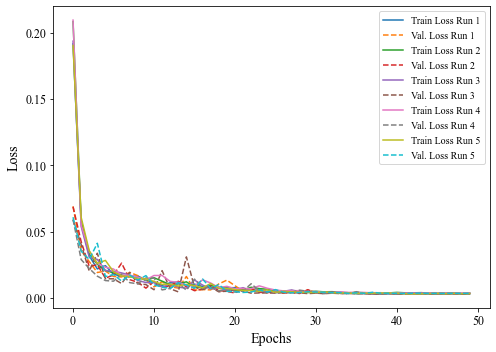

In [22]:
matplotlib.rcParams['font.family'] = 'Times New Roman'
figLoss = plt.figure(figsize=(7, 5))

for i, history in enumerate(histories):
    plt.plot(history.history['loss'], label=f'Train Loss Run {i+1}')
    plt.plot(history.history['val_loss'], label=f'Val. Loss Run {i+1}', linestyle='--')

plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(loc='upper right', fontsize=10)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()


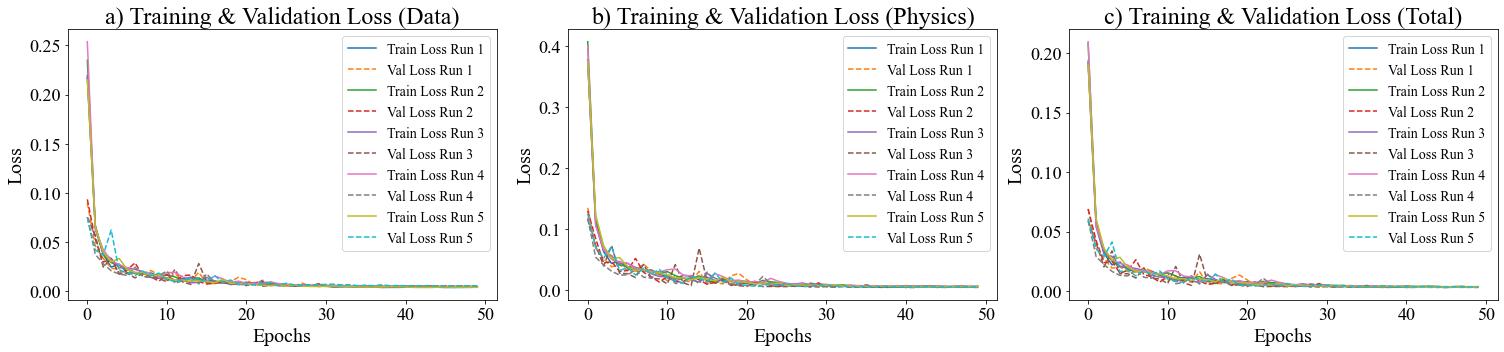

In [23]:
matplotlib.rcParams['font.family'] = 'Times New Roman'
figLoss = plt.figure(figsize=(21, 5))

plt.subplot(1, 3, 1)
for i, history in enumerate(histories):
    plt.plot(history.history['data_loss_metric'], label=f'Train Loss Run {i+1}')
    plt.plot(history.history['val_data_loss_metric'], label=f'Val Loss Run {i+1}', linestyle='--')

plt.title('a) Training & Validation Loss (Data)', fontsize=24)
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
# plt.grid(True)

if 'phys_loss_metric' in histories[0].history.keys():
    plt.subplot(1, 3, 2)
    for i, history in enumerate(histories):
        plt.plot(history.history['phys_loss_metric'], label=f'Train Loss Run {i+1}')
        plt.plot(history.history['val_phys_loss_metric'], label=f'Val Loss Run {i+1}', linestyle='--')

    plt.title('b) Training & Validation Loss (Physics)', fontsize=24)
    plt.xlabel('Epochs', fontsize=20)
    plt.ylabel('Loss', fontsize=20)
    plt.legend(loc='upper right', fontsize=14)
    plt.tick_params(axis='x', labelsize=18)
    plt.tick_params(axis='y', labelsize=18)
    # plt.grid(True)

plt.subplot(1, 3, 3)
for i, history in enumerate(histories):
    plt.plot(history.history['loss'], label=f'Train Loss Run {i+1}')
    plt.plot(history.history['val_loss'], label=f'Val Loss Run {i+1}', linestyle='--')

plt.title('c) Training & Validation Loss (Total)', fontsize=24)
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
# plt.grid(True)

plt.tight_layout()
plt.show()


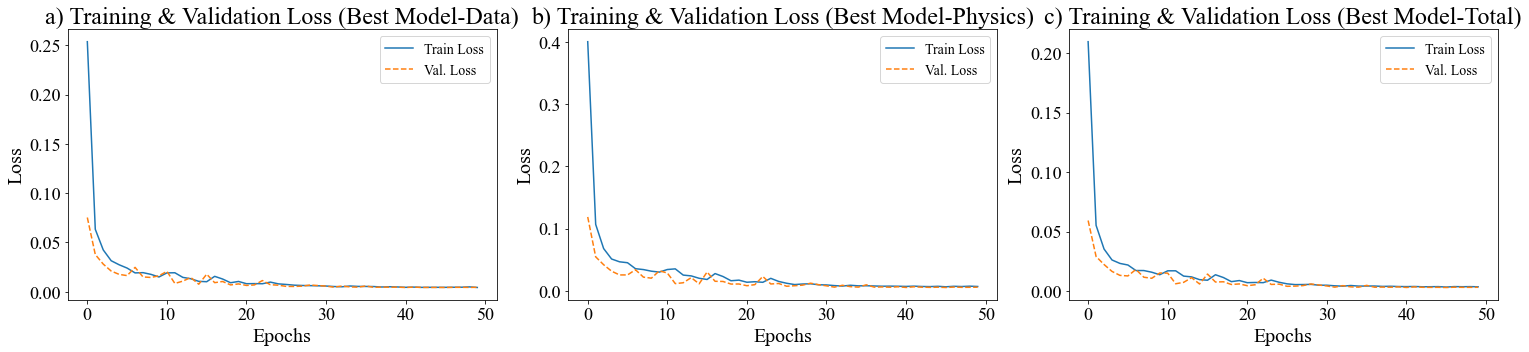

In [24]:
matplotlib.rcParams['font.family'] = 'Times New Roman'
figLoss = plt.figure(figsize=(21, 5)) 

plt.subplot(1, 3, 1)
plt.plot(best_history['data_loss_metric'], label='Train Loss')
plt.plot(best_history['val_data_loss_metric'], label='Val. Loss', linestyle='--')

plt.title('a) Training & Validation Loss (Best Model-Data)', fontsize=24)
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)

plt.subplot(1, 3, 2)
plt.plot(best_history['phys_loss_metric'], label='Train Loss')
plt.plot(best_history['val_phys_loss_metric'], label='Val. Loss', linestyle='--')

plt.title('b) Training & Validation Loss (Best Model-Physics)', fontsize=24)
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)

plt.subplot(1, 3, 3)
plt.plot(best_history['loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val. Loss', linestyle='--')

plt.title('c) Training & Validation Loss (Best Model-Total)', fontsize=24)
plt.xlabel('Epochs', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.legend(loc='upper right', fontsize=14)
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
# plt.grid(True)

plt.tight_layout()
plt.show()


In [25]:
# Predict again using the best model
y_pred_best = best_model.predict(
    [X_wind_test, X_shaft_test, X_gen_t_test, X_gear_t_test, X_current_test, X_voltage_test],
    batch_size=batch_size
)


14/14 [==============================] - 1s 46ms/step


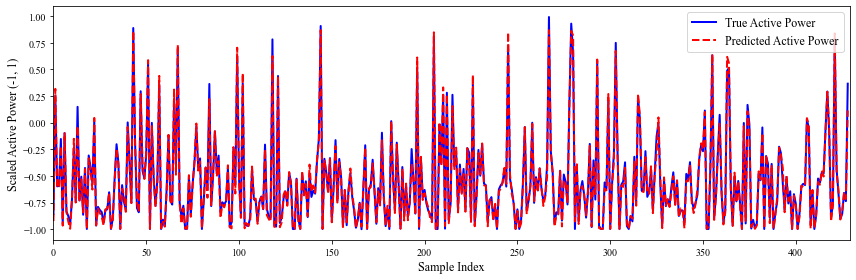

In [26]:
y_test_active = y_test[:, 0]
y_pred_active = y_pred_best[:, 0]

plt.figure(figsize=(12,4))

plt.plot(y_test_active, label='True Active Power', color='blue', linewidth=2)
plt.plot(y_pred_active, label='Predicted Active Power', color='red', linestyle='--', linewidth=2)
# Actual vs Predicted Active Power (Best Model)
plt.xlabel('Sample Index', fontsize=12, fontname='Times New Roman')
plt.ylabel('Scaled Active Power (-1, 1)', fontsize=12, fontname='Times New Roman')
plt.xlim(0,429)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()


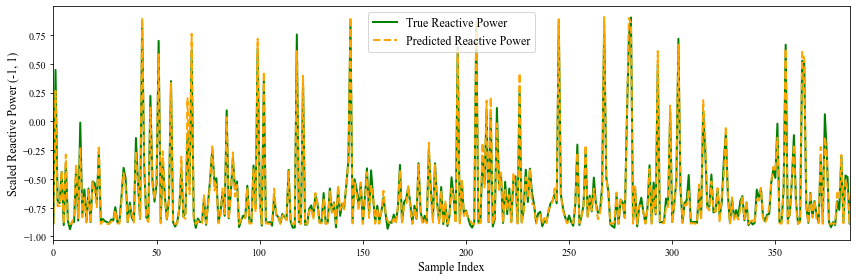

In [27]:
y_test_reactive = y_test[:, 1]    
y_pred_reactive = y_pred_best[:, 1]  

plt.figure(figsize=(12,4))

plt.plot(y_test_reactive, label='True Reactive Power', color='green', linewidth=2)
plt.plot(y_pred_reactive, label='Predicted Reactive Power', color='orange', linestyle='--', linewidth=2)

# Actual vs Predicted Reactive Power
plt.xlabel('Sample Index', fontsize=12, fontname='Times New Roman')
plt.ylabel('Scaled Reactive Power (-1, 1)', fontsize=12, fontname='Times New Roman')
plt.xlim(0,386)
plt.legend(fontsize=12)
#plt.grid(True)
plt.tight_layout()

plt.show()


In [28]:
# ========================================== #

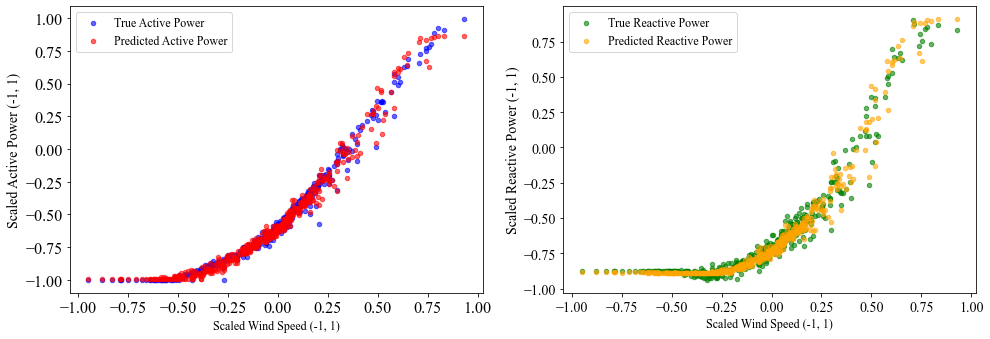

In [29]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 16

plt.figure(figsize=(14, 5))

true_colors = ['blue', 'green']
pred_colors = ['red', 'orange']
labels = ['Active Power', 'Reactive Power']
y_labels = ['Scaled Active Power (-1, 1)', 'Scaled Reactive Power (-1, 1)']

for i in range(2):
    plt.subplot(1, 2, i + 1)
    
    plt.scatter(X_wind_test[:, -1, 0, 0], y_test[:, i],
                color=true_colors[i], alpha=0.6, s=20,
                label=f'True {labels[i]}')
    
    plt.scatter(X_wind_test[:, -1, 0, 0], y_pred_best[:, i],
                color=pred_colors[i], alpha=0.6, s=20,
                label=f'Predicted {labels[i]}')
    
    plt.xlabel('Scaled Wind Speed (-1, 1)', fontsize=12)
    plt.ylabel(y_labels[i], fontsize=14)
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14

    plt.legend(fontsize=12)
    #plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

#plt.suptitle('Predicted vs True Power Output vs Wind Speed', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


In [30]:
# -----------------------------------------

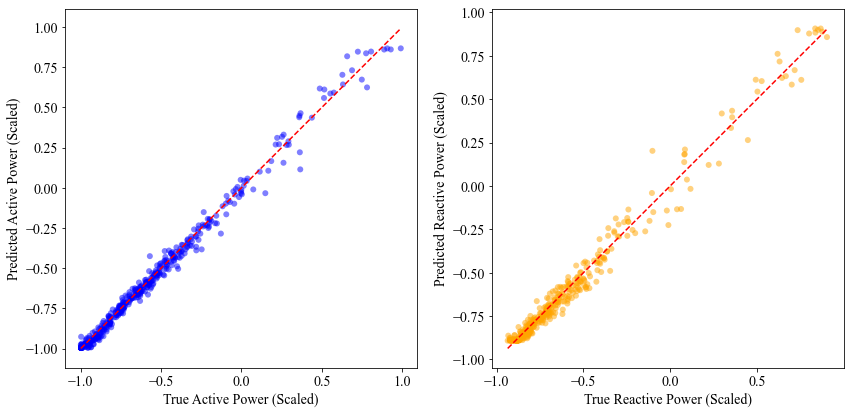

In [31]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16

plt.figure(figsize=(12, 6))

titles = ['Active Power: True vs Predicted', 'Reactive Power: True vs Predicted']
labels = ['Active Power (Scaled)', 'Reactive Power (Scaled)']
colors = ['blue', 'orange']

for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.scatter(
        y_test[:, i], 
        y_pred_best[:, i], 
        alpha=0.5, 
        color=colors[i], 
        edgecolor='none'
    )
    
    min_val = min(y_test[:, i].min(), y_pred_best[:, i].min())
    max_val = max(y_test[:, i].max(), y_pred_best[:, i].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
    
    plt.xlabel(f'True {labels[i]}', fontsize=14)
    plt.ylabel(f'Predicted {labels[i]}', fontsize=14)
    #plt.title(titles[i])
    plt.axis('equal')

plt.tight_layout()
plt.show()


In [32]:
## ---------------------------------------------------------
## ---------------------------------------------------------